## LAB 07: PHÂN ĐOẠN ẢNH (IMAGE SEGMENTATION)

In [1]:
import cv2 as cv
import matplotlib.pyplot as Hiep
import numpy as np

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

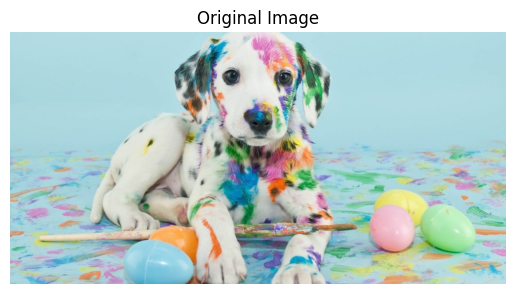

In [3]:
img = cv.imread('hinh1.jpg')


img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

Hiep.imshow(img_rgb)
Hiep.title("Original Image")
Hiep.axis('off')

1. Thresholding để phân đoạn ảnh

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

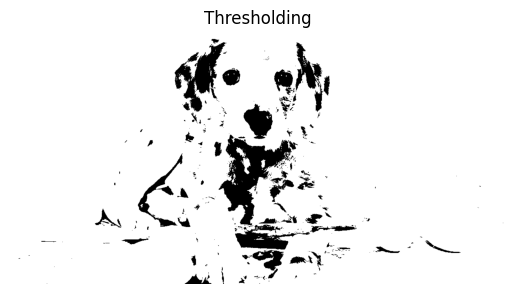

In [4]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

_, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)

Hiep.imshow(thresh, cmap='gray')
Hiep.title("Thresholding")
Hiep.axis('off')

2. Otsu algorithm để phân đoạn ảnh vân tay

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

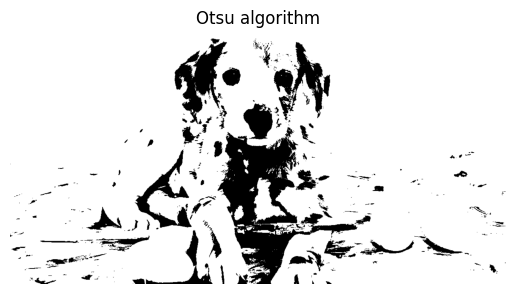

In [15]:
_, otsu = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

Hiep.imshow(otsu, cmap='gray')
Hiep.title("Otsu algorithm")
Hiep.axis('off')

3. Clustering techniques trong phân đoạn ảnh, K-mean clustering

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

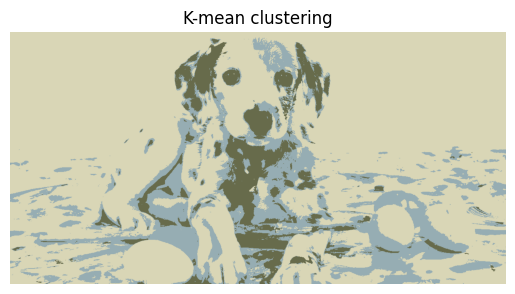

In [14]:
Z = img.reshape((-1,3))
Z = np.float32(Z)

criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 3

ret,label,center = cv.kmeans(Z, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

center = np.uint8(center)
res = center[label.flatten()]
result_image = res.reshape((img.shape))

Hiep.imshow(result_image)
Hiep.title("K-mean clustering")
Hiep.axis('off')

4. Sử dụng thuật toán Region growing

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

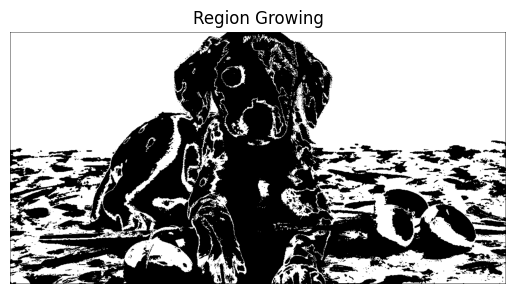

In [7]:
seed_point = (100, 100)
threshold = 10

segmented = np.zeros(gray.shape, np.uint8)
segmented[seed_point] = 255

for i in range(1, gray.shape[0]-1):
    for j in range(1, gray.shape[1]-1):
        if abs(int(gray[i,j]) - int(gray[seed_point])) < threshold:
            segmented[i,j] = 255

Hiep.imshow(segmented, cmap='gray')
Hiep.title("Region Growing")
Hiep.axis('off')

5. Sử dụng thuật toán Split and merge để phân đoạn ảnh

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

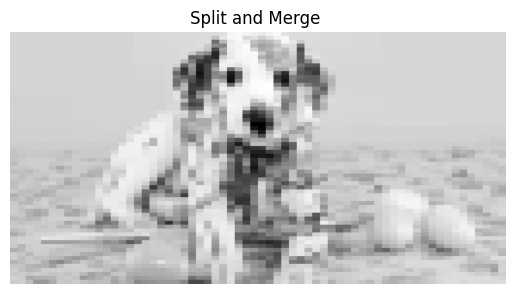

In [11]:
def is_homogeneous(region, threshold=15):
    return np.max(region) - np.min(region) < threshold

def split(region):
    h, w = region.shape


    if h < 16 or w < 16 or is_homogeneous(region):
        return np.mean(region) * np.ones_like(region)

    # Chia 4
    h2, w2 = h//2, w//2

    tl = split(region[:h2, :w2])
    tr = split(region[:h2, w2:])
    bl = split(region[h2:, :w2])
    br = split(region[h2:, w2:])

    # Ghép lại
    top = np.hstack((tl, tr))
    bottom = np.hstack((bl, br))

    return np.vstack((top, bottom))

result = split(gray)

Hiep.imshow(result, cmap='gray')
Hiep.title("Split and Merge ")
Hiep.axis('off')

6. Phân đoạn ảnh với Edge-based sigmentation

(np.float64(-0.5), np.float64(1279.5), np.float64(649.5), np.float64(-0.5))

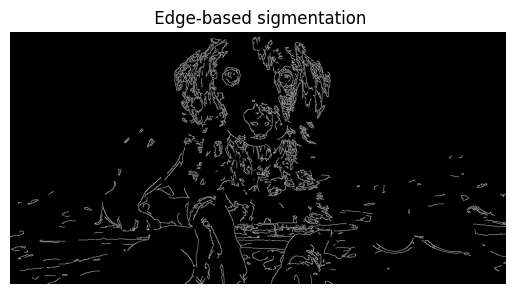

In [13]:
edges = cv.Canny(gray, 100, 200)

Hiep.imshow(edges, cmap='gray')
Hiep.title(" Edge-based sigmentation")
Hiep.axis('off')